# Dimensionality Reduction of 4D-STEM Data Using Autoencoders and Variational Autoencoders

<br>

## Introduction

<br>

Four-dimensional scanning transmission electron microscopy (4D-STEM) records a full diffraction pattern at every probe position of a raster scan, producing data with extremely high spatial and reciprocal-space dimensionality. Extracting physically meaningful deformation modes from such datasets requires methods that can reduce dimensionality while preserving subtle structural signatures.

Shi *et al.* (2022) demonstrated that unsupervised learning applied to carefully selected intensity-variance (STD) features can reveal strain fields and subdomains within transition-metal dichalcogenide (TMD) flakes. Their workflow—STD feature selection followed by hierarchical clustering—successfully identified material contrast and deformation gradients, but relied on explicitly engineered descriptors rather than learned representations.

<br>

## Objective

<br>

The goal of this notebook is to construct *learned* low-dimensional representations of 4D-STEM diffraction patterns using neural architectures, and to evaluate whether these representations can recover the key structural contrasts identified by the classical STD-based approach.

Specifically, we implement and compare:

1. **A deterministic autoencoder (AE)**  
   A fully connected network trained to reconstruct masked diffraction patterns and produce a compact latent code.

2. **A variational autoencoder (VAE)**  
   A probabilistic model that enforces a Gaussian prior on the latent space, yielding smoother and more structured embeddings.

3. **Clustering in learned latent spaces**  
   K-means clustering is applied to the AE and VAE embeddings to obtain real-space segmentations of WS₂ and WSe₂ flakes.

4. **Comparison with the STD baseline**  
   We compare reconstruction behaviour, latent-space geometry, cluster coherence, and center-difference patterns across the STD, AE, and VAE approaches.

<br>

## Structure of the Notebook

- Preprocessing and STD feature selection  
- Baseline clustering using STD descriptors  
- Autoencoder definition, training, and latent-space clustering  
- Variational autoencoder definition, training, and latent-space clustering  
- Visual comparison of cluster maps and center-difference patterns  
- Summary and analysis of STD vs AE vs VAE approaches


<br><br>

### Data Loading and Preprocessing: Alignment and ADF Reconstruction

<br>

The 4D-STEM dataset is first loaded from the provided `.mat` file using helper routines supplied with the course materials. Each scan position contains a nanobeam electron diffraction (NBED) pattern, resulting in a four-dimensional array with dimensions corresponding to the real-space scan and reciprocal-space coordinates.

<br>

Upon loading, the dataset is wrapped in a convenience class (`FileClass`) that provides standardized preprocessing operations. The diffraction patterns are then aligned by recentering the direct beam, which reduces scan distortions and ensures that subsequent feature extraction is based on physically consistent patterns.

<br>

An annular dark-field (ADF) image is reconstructed from the aligned 4D dataset. This projection is obtained by integrating the intensity in the high-angle scattering region of each diffraction pattern and serves as a real-space representation of sample thickness and composition. The ADF image is displayed to verify that the alignment and data import have been performed correctly.


In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline


In [2]:
# Import the Node class and the helper functions

from   root_class        import *
import helper_function   as hf

# Import necessary packages

import numpy             as np
import matplotlib.pyplot as plt
import h5py

C:\Users\Huseyn\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
file_path = 'C:/Users/Huseyn/OneDrive - Baku Higher Oil School/Desktop/Data Science for Electron Microscopy and Machine Learning in Microscopy/Miniproject/cbed_wide2.mat'


In [4]:
data = hf.read_4D(file_path)


In [5]:
wide_node = FileClass(data)

In [6]:
wide_node.alignment()

 255,255          Mean of the center =  (np.float64(61.807618210505865), np.float64(61.80776413447728))
Std of the center =  (np.float64(0.0045132229853385875), np.float64(0.0044357357002577525))


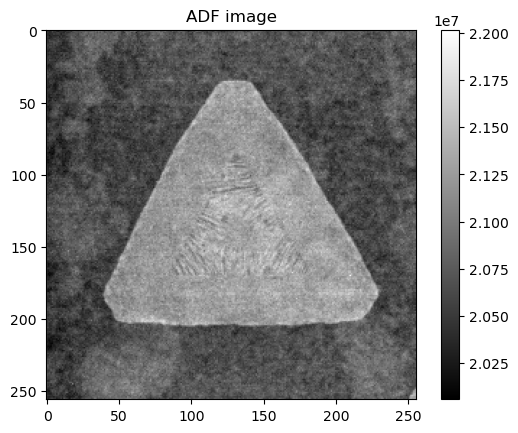

In [7]:
adf_image = wide_node.getADF()

plt.title('ADF image')
plt.imshow(adf_image, cmap='gray')
plt.colorbar()
plt.show()

The annular dark-field (ADF) image reconstructed from the aligned 4D-STEM dataset is shown above. This projection highlights thickness and composition variations within the triangular flake and is used to verify correct alignment and data integrity before further analysis.

<br><br>

### Log-STD Map Computation

<br>

A logarithmic standard-deviation (log-STD) map is computed from the aligned 4D-STEM dataset.  
For each scan position, the pixelwise standard deviation of the diffraction intensities across reciprocal space is evaluated, and the logarithm of this quantity is taken to enhance contrast.

<br>

This map highlights regions where significant variations in diffraction intensity occur, which are typically related to strain, lattice tilts, or local structural distortions. High-STD regions correspond to areas of strong structural contrast and serve as the primary features for subsequent masking and clustering. The log-STD map is visualized to verify that the structural features expected from the sample are detectable.


In [8]:
log_std_map = wide_node.getLogStdMap()

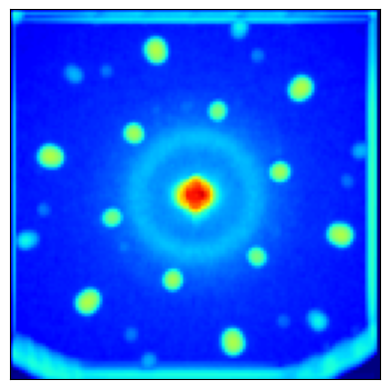

In [9]:
# plt.title('std map')
plt.imshow(log_std_map, vmin = 1,vmax = 10, cmap='jet')
# plt.colorbar()

plt.xticks([]); plt.yticks([])
plt.show()

The logarithmic standard-deviation (log-STD) map of the diffraction patterns is shown above. The bright spots in the color scale correspond to reciprocal-lattice peaks whose intensities fluctuate strongly across the scan, whereas the surrounding lower-intensity regions reflect more uniform background scattering.


<br><br>

### Radial–Angular Intensity Representation

<br>

A radial–angular (r–θ) representation of the diffraction data is generated to visualize the angular dependence of the scattering intensity.  
For each diffraction pattern, the intensity is integrated as a function of radius and scattering angle, producing a 2D map that reveals symmetries, lattice rotations, and anisotropic scattering features.

<br>

This representation provides a complementary view to the log-STD map and is useful for identifying global crystallographic orientation or rotational gradients in the sample. The resulting r–θ plot is displayed for inspection of angular features that may contribute to downstream clustering.


In [10]:
r_theta_map = wide_node.getRThetaPlot()

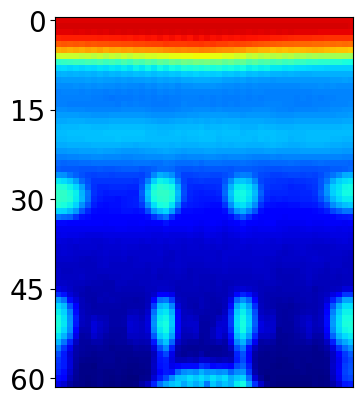

In [11]:
plt.subplot(111)

# plt.title('std map')
plt.imshow(r_theta_map, vmax = 2.4,cmap='jet')
plt.xticks([])
plt.yticks(np.arange(0,70,15), fontsize = 20)
# plt.colorbar()
plt.show()

The r–θ representation of the diffraction data is shown above, where each diffraction pattern has been transformed from Cartesian pixel coordinates into radial–angular coordinates. Bright arcs along the radial direction correspond to Bragg rings from different reciprocal-lattice spacings, while localized bright spots along the angular direction indicate azimuthal intensity variations associated with lattice orientation or symmetry-breaking features.

<br><br>

### Reciprocal-Space Masking

<br>

A reciprocal-space mask is applied to each diffraction pattern to isolate the scattering region that contains the most relevant structural information.  
The inner and outer radii (`in_r` and `out_r`) define an annular region in which intensities are preserved, while intensities outside this region are excluded.

<br>

This masking suppresses low-angle background, noise, and detector artifacts, ensuring that subsequent dimensionality reduction focuses on the physically meaningful scattering signal. After masking, a new log-STD map is computed to confirm that the retained region captures the dominant structural contrast.


In [12]:
in_r = 24; out_r = 57; 

wide_node.getMasked(in_r, out_r)

In [13]:
log_std_map2 = wide_node.getLogStdMap()

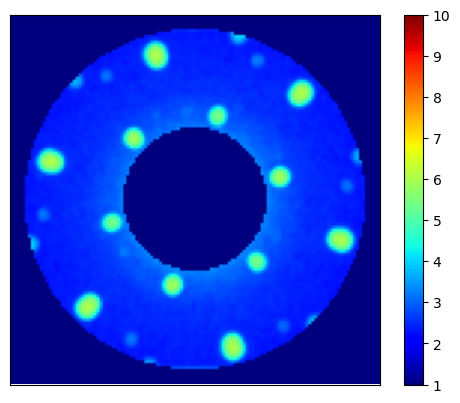

In [14]:
# plt.title('std map')
plt.imshow(log_std_map2,vmin = 1,vmax = 10, cmap='jet')
plt.xticks([]); plt.yticks([])
plt.colorbar()
plt.show()

The masked log-STD map

<br><br>


### High-Variance Pixel Selection

<br>

To further reduce input dimensionality and emphasize the structurally informative regions, a threshold is applied to the STD map.  
Pixels with standard-deviation values below 30% of the global maximum are identified and set to zero, effectively removing low-contrast or noise-dominated regions.

<br>

This step produces a sparse mask that retains only the most deformation-sensitive scattering pixels, consistent with the feature-selection strategy used by Shi et al. (2022). The thresholded STD map is visualized to verify that only high-variance pixels remain.


In [15]:
sel = log_std_map2 < np.max(log_std_map) * 0.3
log_std_map2[sel] = 0

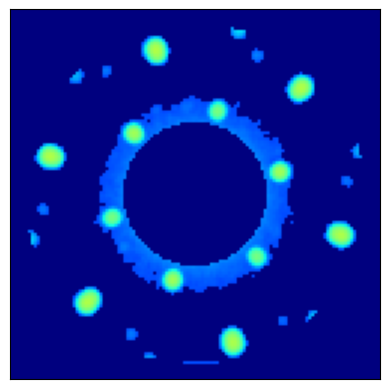

In [16]:
# plt.title('std map')
plt.imshow(log_std_map2, vmin=1, vmax = 10,cmap='jet')
plt.xticks([]); plt.yticks([])
# plt.colorbar()
plt.show()

The thresholded log-STD map.

<br><br>

### STD-Based Feature Selection and Manifold Visualization

<br>

A binary mask is constructed from the thresholded log-STD map in order to retain only the diffraction pixels exhibiting high intensity variance. Pixels whose log-STD values fall below 30% of the global maximum are marked as inactive, while the remaining high-variance pixels are preserved. This mask reflects the subset of reciprocal-space locations that carry the most significant structural information.

<br>

The mask is then applied to the diffraction patterns using the `getStdMasked` routine, which extracts the corresponding subset of intensities for every scan position. This results in a reduced representation of the 4D-STEM dataset in which irrelevant or low-contrast pixels have been removed, substantially decreasing the dimensionality prior to clustering or neural-network processing.

<br>

To assess the global structure of the reduced dataset, a nonlinear embedding (referred to as the “manifold”) is computed through the `getManifold` method. This produces a low-dimensional representation in which similar diffraction patterns are placed near one another. A three-dimensional scatter plot is generated to visualize the manifold structure, allowing coherent domains or deformation-related variations to be inspected before further analysis.


In [17]:
sel = log_std_map2<np.max(log_std_map) * 0.3

In [18]:
std_mask = np.ones(np.shape(log_std_map2))
std_mask[sel] = 0

In [19]:
threshold = np.max(log_std_map) * 0.3
wide_node.getStdMasked(threshold=threshold)

In [20]:
manifold = wide_node.getManifold()

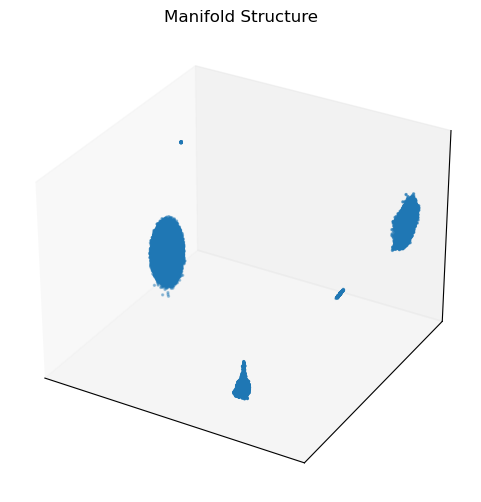

In [21]:
# Plot the manifold structure of the whole dataset
fig = plt.figure(figsize=(6,6))

ax1  = fig.add_subplot(111, projection='3d')
im  = ax1.scatter(manifold[:,0], manifold[:,1], 
                  manifold[:,2],s=2)
plt.title('Manifold Structure')
plt.xticks([]),plt.yticks([])
ax1.set_zticks([])
plt.show()

A three-dimensional manifold embedding of the STD-masked diffraction data is shown above. Each point represents a single scan position projected into a low-dimensional space constructed from the principal components of the masked intensities. The emergence of several compact, well-separated point clouds indicates that distinct regions of the sample produce systematically different diffraction signatures. These clusters reflect underlying structural variations, such as strain fields, rotational domains, or compositional differences, that persist across neighboring scan positions.

<br><br>

### Baseline Clustering Using STD-Reduced Diffraction Features

<br>

A baseline segmentation is obtained by applying K-means clustering to the STD-reduced diffraction vectors.  
The `ClusterClass` is initialized with the original 4D-STEM data and the corresponding masked feature set, enabling clustering to be performed in the reduced reciprocal-space representation defined earlier.

<br>

The number of clusters is estimated through the sum-of-squared-error (SSE) analysis, where the `choose_k_cluster` function evaluates the SSE curve and indicates an appropriate value of \( k \). Once the optimal cluster count is identified, K-means is executed via `getCluster`, and each scan position is assigned to a cluster label.

<br>
The cluster labels are subsequently mapped back to their spatial coordinates using `getRealSpaceMap`. The resulting segmentation provides a reference for the later comparison with the autoencoder and variational autoencoder embeddings. This baseline reflects the performance of classical feature engineering based solely on high-variance diffraction pixels.


In [22]:
cluster_node = ClusterClass(data= wide_node.data, cluster_data=wide_node.std_masked_data)


In [23]:
sse1 = cluster_node.choose_k_cluster(False)

2


In [24]:
cluster_node.getCluster()

C:\Users\Huseyn\anaconda3\envs\torch\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


In [25]:
real_space_map = cluster_node.getRealSpaceMap()

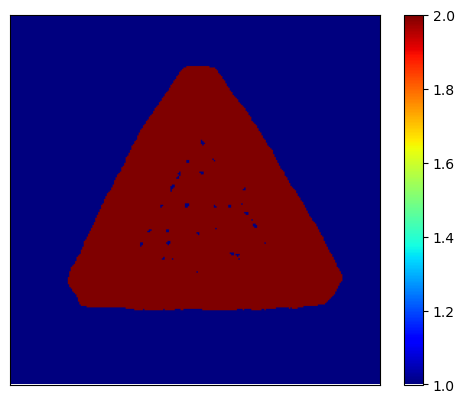

In [26]:
plt.imshow(real_space_map, cmap='jet')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

The baseline K-means clustering result in real space is shown above, where each pixel is colored according to its assigned cluster label. The segmentation separates the triangular flake from the surrounding background based on the STD-masked diffraction features, demonstrating that the handcrafted high-variance pixels already provide a robust contrast between sample and vacuum.


<br><br>

### Visualization of Cluster-Center Diffraction Signatures

<br>

The representative diffraction pattern associated with each cluster is obtained through the `getClusterCenters` method.  
These centers correspond to the mean masked diffraction intensities of all scan positions assigned to a given cluster and therefore characterize the dominant scattering features present within each region of the segmentation.

<br>

To facilitate interpretation, each cluster center is multiplied by the previously constructed STD mask, ensuring that only the high-variance, structurally informative pixels are visualized. This highlights the reciprocal-space regions responsible for distinguishing one cluster from another.

<br>

By examining these cluster-center patterns, differences in lattice orientation, strain contrast, or other deformation-related signatures can be identified, providing insight into the physical origins of the spatial segmentation produced by the baseline clustering.


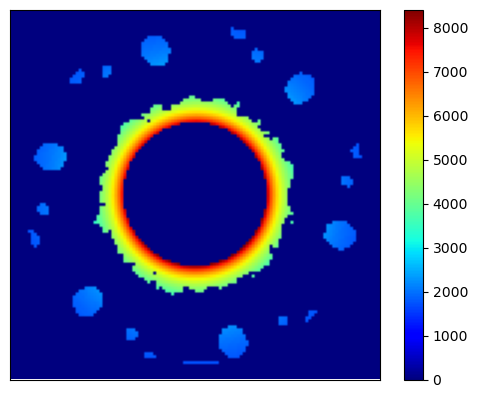

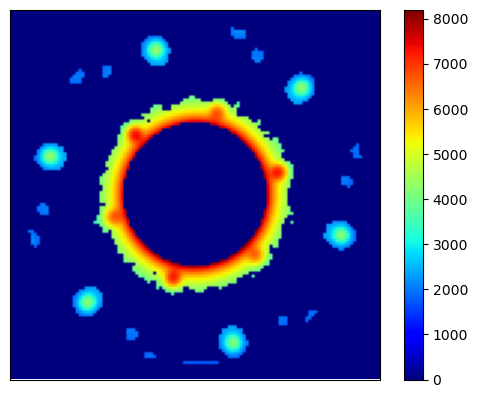

In [27]:
centers = cluster_node.getClusterCenters()
for i in range(len(centers)):
    plt.imshow(centers[i] * std_mask, cmap='jet')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
    plt.show()

This map shows the average masked diffraction pattern of the first cluster obtained from K-means.
Pixels with high values (red–yellow) correspond to reciprocal-space regions that vary strongly across scan positions and therefore dominate the cluster assignment. In this cluster, the diffraction ring is bright and symmetric, indicating a region with uniform strain and well-preserved lattice periodicity.

<br>

The second cluster-center pattern exhibits brighter and more sharply defined Bragg disks relative to the first cluster.
This behaviour suggests scan regions where local variations (e.g., subtle lattice rotations or enhanced strain gradients) shift or intensify specific reciprocal-space peaks, producing a distinctly different diffraction signature than the first cluster.

<br><br>

### Difference Map Between Cluster-Center Diffraction Patterns

<br>

A direct comparison between cluster centers is performed by subtracting one representative diffraction pattern from another.  
The difference map highlights the reciprocal-space regions in which the two clusters exhibit the largest contrast, thereby revealing which scattering features are responsible for their separation during clustering.

<br>

The difference is multiplied by the STD mask to restrict the visualization to the high-variance pixels that encode structural information.  
Positive and negative regions in the map correspond to intensities that are respectively stronger or weaker in one cluster relative to the other, allowing deformation- or orientation-related distinctions to be identified more clearly.


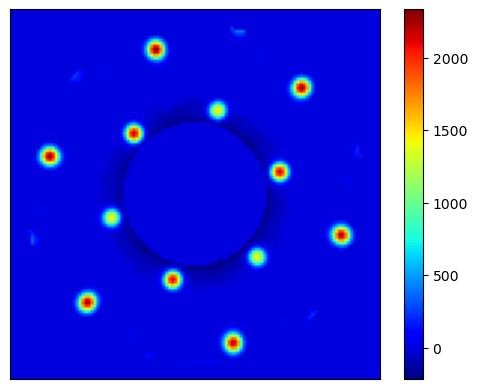

In [28]:
plt.imshow((centers[1] - centers[0]) * std_mask, cmap='jet')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

The image displays the pixel-wise difference between the two cluster-center diffraction patterns after masking.
Bragg disks that appear bright indicate reciprocal-space regions where the second cluster exhibits systematically higher intensity, while dark regions correspond to features stronger in the first cluster.

<br><br>


### Hierarchical Refinement of STD-Based Clustering

<br>

To resolve finer structural variations that are not captured at the first clustering level, a hierarchical refinement is performed. The initial clusters obtained from the STD-reduced feature space are subdivided using the `getSubClusters` routine, which partitions each primary cluster into smaller, more homogeneous groups.

<br>

A specific branch of the hierarchy is selected for further analysis, and the optimal number of secondary clusters is estimated using the SSE-based criterion through `choose_k_cluster`. Once the value of \( k \) is determined, K-means is applied again to this subset of data using `getCluster`, and a refined real-space segmentation map is generated via `getRealSpaceMap`. This map reveals intra-cluster structural variations that are not visible at the coarse clustering level.

<br>

For interpretation, the representative diffraction patterns of the secondary clusters are computed using `getClusterCenters`. Each secondary cluster center is compared against the corresponding primary cluster center by subtracting one from the other, after multiplication with the STD mask. These difference maps highlight the reciprocal-space regions where subtle but systematic intensity changes occur, indicating variations such as slight lattice distortions, local strain gradients, or orientation splitting within the originally merged region.


In [29]:
cluster_node.getSubClusters()
sample_node = cluster_node.sub_clusters[1]

In [30]:
sse2 = sample_node.choose_k_cluster(False)

2


C:\Users\Huseyn\anaconda3\envs\torch\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


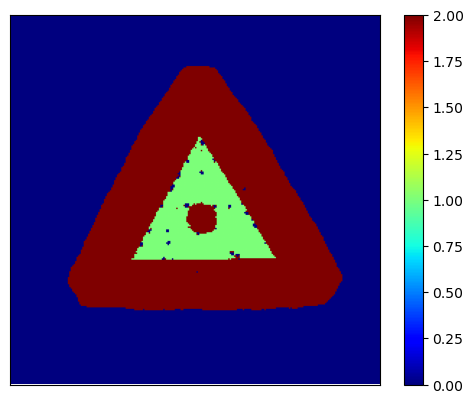

In [31]:
sample_node.getCluster()
real_space_map2 = sample_node.getRealSpaceMap()
plt.imshow(real_space_map2, cmap='jet')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

The second-level subdivision of one of the initial clusters, revealing two distinct regions inside the triangular flake. The inner area exhibits diffraction statistics that differ from the outer domain, indicating a localized change in lattice configuration or strain state.

<br><br>

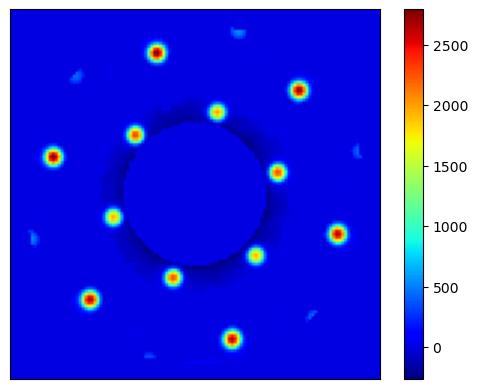

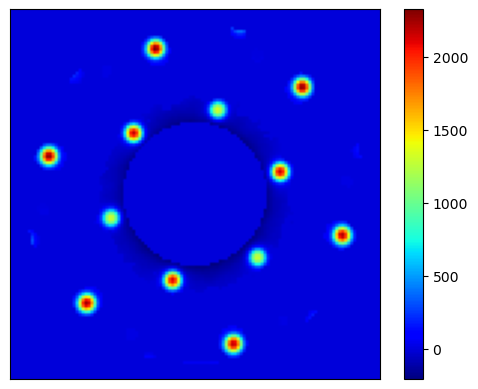

In [32]:
centers_sample = sample_node.getClusterCenters()
for i in range(len(centers_sample)):
    plt.imshow((centers_sample[i]-centers[0]) * std_mask, cmap = 'jet')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
    plt.show()

The 1st center-difference map highlights reciprocal-space regions where the subcluster exhibits higher diffraction intensity than the parent cluster.

<br>

The second subcluster shows a different pattern of intensity enhancements, with several Bragg disks brightening relative to the parent cluster. These differences point to localized changes in lattice orientation or strain that distinguish this region from both the parent cluster and the other subcluster.

<br><br>


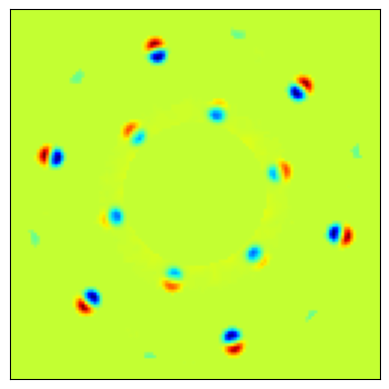

In [33]:
plt.imshow((centers_sample[1] - centers[1]) * std_mask, cmap='jet')
plt.xticks([])
plt.yticks([])
# plt.colorbar()
plt.show()

This map shows the pixel-wise difference between the second-level cluster center and its parent cluster, revealing localized sign changes in Bragg-disk intensities. The paired red–blue lobes indicate systematic angular shifts or asymmetries in the diffraction peaks, consistent with small lattice rotations or shear-like distortions within that region.

<br><br>

### Final-Level Subclustering: Separation of WS₂ and WSe₂ Domains

<br>

A third level of hierarchical refinement is performed to isolate the two principal material phases present in the selected region, corresponding to WS₂ and WSe₂. After the second-level subdivision, the branch of interest is further partitioned using `getSubClusters`, which produces two distinct sub-nodes associated with these phases.

<br>

For each phase, the optimal number of clusters is estimated through the SSE analysis via `choose_k_cluster`. K-means clustering is then applied independently to the WS₂ and WSe₂ subsets using `getCluster`, yielding refined real-space segmentation maps that reveal internal structural variability within each material region.

<br>

The representative diffraction signatures of each refined cluster are obtained through `getClusterCenters`. To interpret these clusters, the center patterns are compared against the first-level cluster center by subtracting the masked intensities. This highlights the reciprocal-space features that differentiate the WS₂- and WSe₂-associated clusters from the broader parent region.

<br>

Additionally, intra-phase differences are examined by subtracting the WS₂ cluster centers from one another, providing insight into subtle variations such as local strain modulations or orientation changes within the WS₂ domains. A similar analysis is performed for the WSe₂ phase, where differences among phase-specific cluster centers reflect its internal heterogeneity. This final hierarchical step yields the most fine-grained segmentation of the STD-reduced dataset.

In [34]:
sample_node.getSubClusters()
WS2_node  = sample_node.sub_clusters[0]
WSe2_node = sample_node.sub_clusters[1]

In [35]:
WS2_sse = WS2_node.choose_k_cluster(False)

4


C:\Users\Huseyn\anaconda3\envs\torch\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


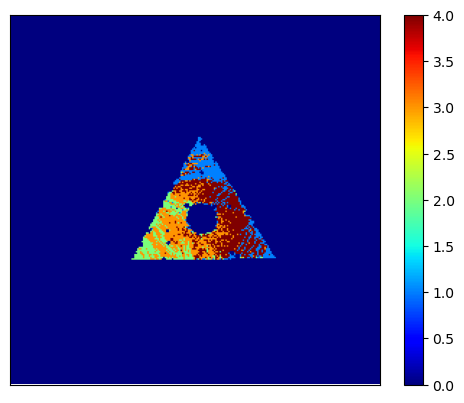

In [36]:
WS2_node.getCluster()
real_space_map_WS2 = WS2_node.getRealSpaceMap()
plt.imshow(real_space_map_WS2, cmap='jet')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

This real-space cluster map displays the fine-grained subdivision of the WS₂-dominated region, where four distinct structural domains are identified. The spatial variation across the flake indicates localized changes in diffraction behavior, consistent with heterogeneous strain or orientation differences within the WS₂ portion of the sample.

<br><br>


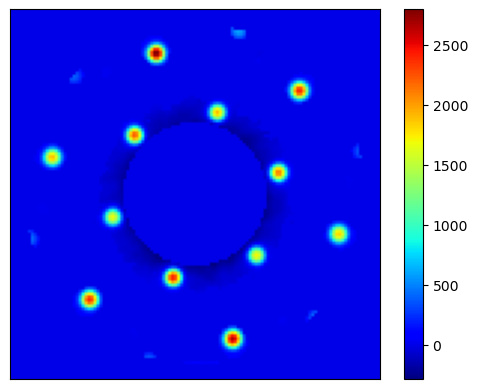

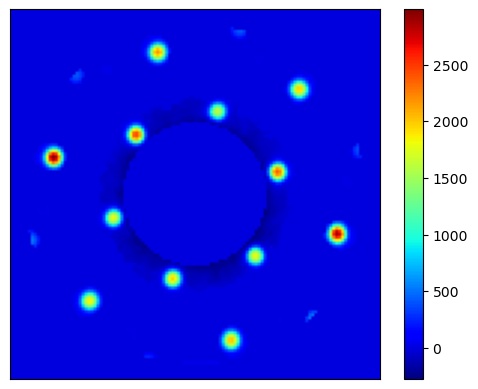

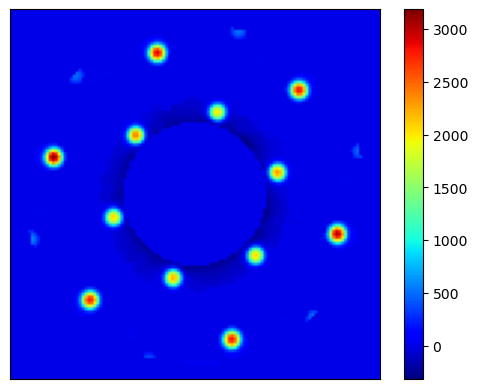

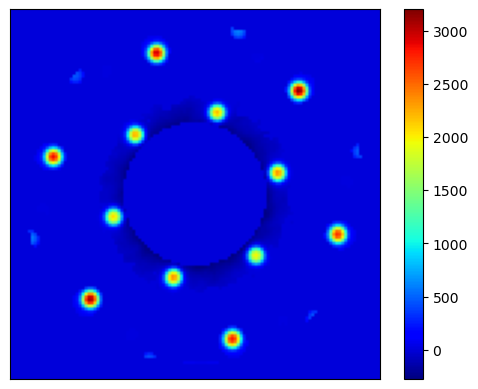

In [37]:
centers_WS2        = WS2_node.getClusterCenters()
for i in range(len(centers_WS2)):
    plt.imshow((centers_WS2[i] - centers[0]) * std_mask, cmap = 'jet')
    plt.xticks([])
    plt.yticks([])
    plt.colorbar()
    plt.show()

These four center-difference patterns represent the diffraction signatures of the WS₂ subclusters, each highlighting Bragg-disk intensities that deviate from the parent-domain average. The distinct variations across the subclusters indicate the presence of multiple localized strain or orientation states within the WS₂ region of the flake.

<br><br>


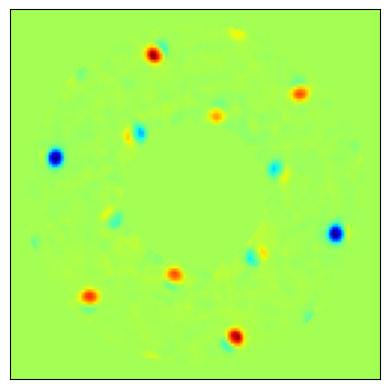

In [38]:
plt.imshow(centers_WS2[0]-centers_WS2[1], cmap = 'jet')
plt.xticks([])
plt.yticks([])
plt.show()

This difference map highlights the reciprocal-space features that distinguish the first two WS₂ subclusters, with red and blue lobes marking scattering vectors where their diffraction intensities diverge.

<br><br>


In [39]:
sse_WSe2 = WSe2_node.choose_k_cluster(False)

4


C:\Users\Huseyn\anaconda3\envs\torch\Lib\site-packages\sklearn\cluster\_kmeans.py:1955: UserWarning: MiniBatchKMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can prevent it by setting batch_size >= 1536 or by setting the environment variable OMP_NUM_THREADS=4
  warnings.warn(


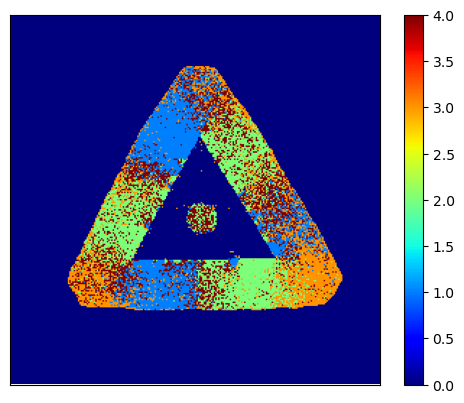

In [40]:
WSe2_node.getCluster()
real_space_map_WSe2 = WSe2_node.getRealSpaceMap()
centers_WSe2= WSe2_node.getClusterCenters()
plt.imshow(real_space_map_WSe2, cmap='jet')
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

Real-space map presents the four subclusters identified within the WSe₂ region, revealing pronounced spatial heterogeneity across the triangular flake.

<br><br>


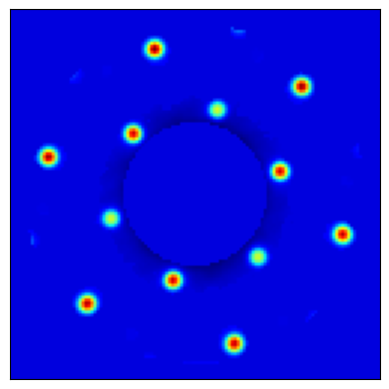

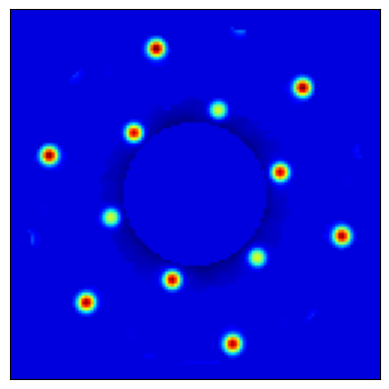

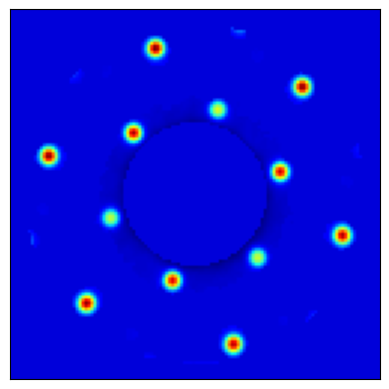

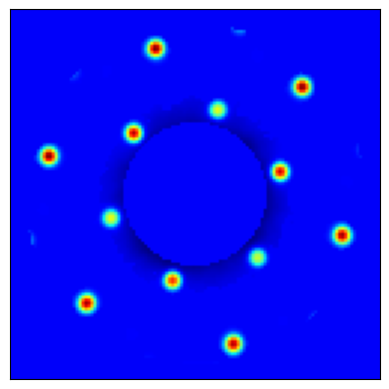

In [41]:
for i in range(len(centers_WSe2)):
    plt.imshow((centers_WSe2[i] -centers[0] )* std_mask, cmap = 'jet')
    plt.xticks([])
    plt.yticks([])
    plt.show()

These four center-difference patterns visualize the reciprocal-space variations that distinguish the WSe₂ subclusters, revealing consistent shifts in Bragg-disk intensities that reflect multiple localized strain or orientation states within the WSe₂ domain.

<br><br>

## Autoencoder-Based Dimensionality Reduction and Clustering

<br><br>

In this section, a fully connected autoencoder (AE) is used to obtain a learned low-dimensional representation of the STD-masked diffraction data, with the focus placed on the interior of the flake rather than on the surrounding vacuum.

<br>

First, the 3D array of masked diffraction patterns `wide_node.std_masked_data` with shape  

<br>

$$(N_x,\, N_y,\, D_{\text{masked}})$$  

<br>

is combined with the high-STD real-space mask `std_mask`. Only scan positions with `std_mask > 0` are retained, yielding  

<br>

$$N_{\text{valid}}$$  

<br>

positions inside the flake. The corresponding diffraction data are reshaped into a matrix 

<br>

$$X \in \mathbb{R}^{\,N_{\text{valid}} \times D_{\text{masked}}},$$

<br>

where each row contains the intensities of the masked reciprocal-space pixels for one scan position.

<br>

To preserve relative variance between reciprocal-space pixels while ensuring stable optimization, each feature (i.e., each masked pixel) is standardized independently across the valid scan positions. For every column of $X$, the mean is subtracted and the result is divided by the empirical standard deviation, so that the standardized matrix $X_{\text{std}}$ has approximately zero mean and unit variance.

<br>

The standardized data matrix $X_{\text{std}}$ is then converted into a PyTorch dataset and data loader, enabling mini-batch training on CPU or GPU. An autoencoder network is defined with

- an input layer of dimension $D_{\text{masked}}$,  
- two hidden layers of width $512$ in both encoder and decoder,  
- and a latent layer of dimension  
  $$\texttt{latent\_dim\_ae} = 8.$$

The encoder maps each standardized diffraction vector  

<br>

$$x \in \mathbb{R}^{D_{\text{masked}}}$$  

<br>

to a latent code  

<br>

$$z \in \mathbb{R}^{8},$$  

<br>

and the decoder maps $z$ back to a reconstruction $\hat{x}$ in the original feature space.

<br>

The network is trained by minimizing the mean-squared reconstruction error  

<br>

$$\mathcal{L}_{\mathrm{AE}} = \lVert x - \hat{x} \rVert^{2}$$ 

<br>

using the Adam optimizer over $40$ epochs. During training, the average reconstruction loss per epoch is printed to verify convergence.

<br>

After training, the autoencoder is switched into evaluation mode and latent codes are computed for all valid scan positions, yielding a latent matrix  

<br>

$$Z_{\mathrm{AE}} \in \mathbb{R}^{\,N_{\text{valid}} \times 8}.$$  

<br>

K-means clustering with  

<br>

$$k = 4$$  

<br>

is then applied in this latent space. Each valid scan position is assigned a cluster label, and these labels are written back into a full real-space map of size $(N_x, N_y)$, with pixels outside the STD mask set to $-1$.

<br>

To visualize the organization of the learned embedding, the 8-dimensional latent codes are further projected onto three principal components using PCA, and the resulting 3D coordinates  

<br>

$$(\mathrm{PC1},\, \mathrm{PC2},\, \mathrm{PC3})$$

<br>

are plotted with coloring according to their K-means label. This low-dimensional visualization enables direct comparison between the AE-based separation of patterns and the baseline clustering derived from handcrafted STD features.


WS2: region_mask shape: (256, 256)
WS2: X (region) shape: (3799, 2086)
WS2: X_std mean/std = 3.2655950832349845e-08 1.0
WS2: using device cuda
[WS2 AE] Epoch 1/40, loss = 9.713713e-01
[WS2 AE] Epoch 5/40, loss = 8.679814e-01
[WS2 AE] Epoch 10/40, loss = 8.507458e-01
[WS2 AE] Epoch 15/40, loss = 8.365995e-01
[WS2 AE] Epoch 20/40, loss = 8.213931e-01
[WS2 AE] Epoch 25/40, loss = 8.053579e-01
[WS2 AE] Epoch 30/40, loss = 7.883824e-01
[WS2 AE] Epoch 35/40, loss = 7.726570e-01
[WS2 AE] Epoch 40/40, loss = 7.570629e-01
WS2: Z_reg shape: (3799, 8)
WS2: labels_reg shape: (3799,)


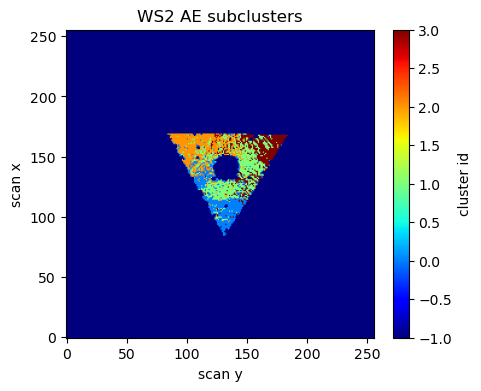

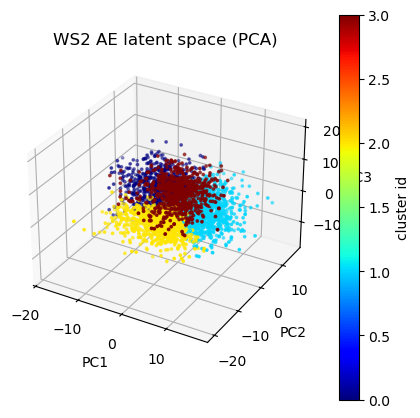

WSe2: region_mask shape: (256, 256)
WSe2: X (region) shape: (16268, 2086)
WSe2: X_std mean/std = -1.394898163198377e-06 1.0000005960464478
WSe2: using device cuda
[WSe2 AE] Epoch 1/40, loss = 9.337425e-01
[WSe2 AE] Epoch 5/40, loss = 8.879391e-01
[WSe2 AE] Epoch 10/40, loss = 8.774469e-01
[WSe2 AE] Epoch 15/40, loss = 8.677770e-01
[WSe2 AE] Epoch 20/40, loss = 8.589552e-01
[WSe2 AE] Epoch 25/40, loss = 8.499139e-01
[WSe2 AE] Epoch 30/40, loss = 8.419779e-01
[WSe2 AE] Epoch 35/40, loss = 8.342352e-01
[WSe2 AE] Epoch 40/40, loss = 8.272634e-01
WSe2: Z_reg shape: (16268, 8)
WSe2: labels_reg shape: (16268,)


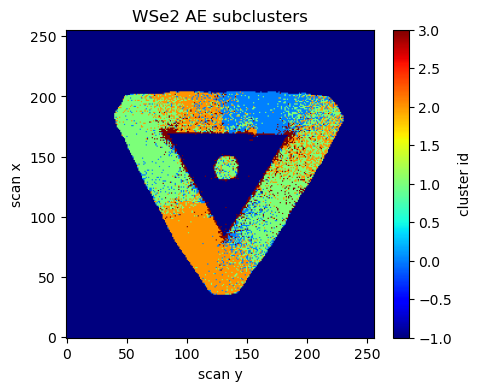

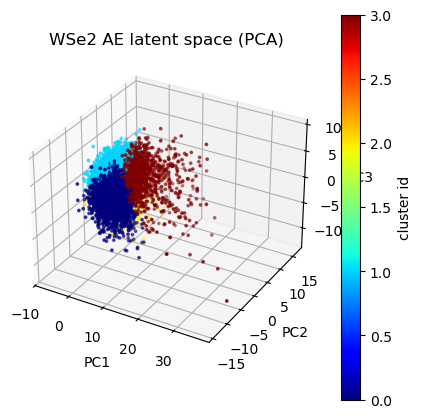

In [60]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Define a function which will train an AE only on diffraction patterns within region_mask, then KMeans-cluster their latent codes and map back to real space.
def ae_latent_subclustering(region_mask, k_sub=4, latent_dim=8, hidden_dim=512,
                            num_epochs=40, batch_size=256, region_name="WS2"):
    masked = wide_node.std_masked_data          # (Nx, Ny, D_masked)
    Nx, Ny, D_masked = masked.shape

    # Restricting to region
    region_mask = (region_mask > 0)
    print(f"{region_name}: region_mask shape:", region_mask.shape)

    masked_flat = masked.reshape(Nx * Ny, D_masked)
    region_flat = region_mask.reshape(Nx * Ny)

    X = masked_flat[region_flat].astype(np.float32)
    print(f"{region_name}: X (region) shape:", X.shape)

    # feature-wise standardization
    feat_mean = X.mean(axis=0, keepdims=True)
    feat_std  = X.std(axis=0, keepdims=True) + 1e-6
    X_std     = (X - feat_mean) / feat_std
    print(f"{region_name}: X_std mean/std =",
          float(X_std.mean()), float(X_std.std()))

    # PyTorch dataset
    X_tensor = torch.from_numpy(X_std)
    dataset  = TensorDataset(X_tensor)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"{region_name}: using device", device)

    input_dim = X_std.shape[1]

    class AutoEncoder(nn.Module):
        def __init__(self, input_dim, latent_dim=8, hidden_dim=512):
            super().__init__()
            self.encoder = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, latent_dim)
            )
            self.decoder = nn.Sequential(
                nn.Linear(latent_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, input_dim)
            )

        def forward(self, x):
            z = self.encoder(x)
            x_recon = self.decoder(z)
            return x_recon, z

    ae = AutoEncoder(input_dim=input_dim,
                     latent_dim=latent_dim,
                     hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(ae.parameters(), lr=1e-3)
    criterion = nn.MSELoss(reduction="mean")

    # Train
    ae.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)

            optimizer.zero_grad()
            recon, z = ae(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch.size(0)

        avg_loss = total_loss / len(dataset)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[{region_name} AE] Epoch {epoch+1}/{num_epochs}, "
                  f"loss = {avg_loss:.6e}")

    # Latent codes
    ae.eval()
    with torch.no_grad():
        X_dev = X_tensor.to(device)
        _, Z_reg = ae(X_dev)
        Z_reg = Z_reg.cpu().numpy()
    print(f"{region_name}: Z_reg shape:", Z_reg.shape)

    # Clustering in latent space
    kmeans = KMeans(n_clusters=k_sub, n_init=10, random_state=0)
    labels_reg = kmeans.fit_predict(Z_reg)
    print(f"{region_name}: labels_reg shape:", labels_reg.shape)

    # Mapping back to full real-space label map (background=-1)
    label_map = -1 * np.ones(Nx * Ny, dtype=int)
    label_map[region_flat] = labels_reg
    label_map = label_map.reshape(Nx, Ny)

    plt.figure(figsize=(5, 4))
    im = plt.imshow(label_map, origin="lower", cmap="jet")
    plt.title(f"{region_name} AE subclusters")
    plt.colorbar(im, label="cluster id")
    plt.xlabel("scan y")
    plt.ylabel("scan x")
    plt.show()

    # PCA to 3D for visualization
    pca = PCA(n_components=3)
    Z_reg_3d = pca.fit_transform(Z_reg)

    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection="3d")
    p = ax.scatter(Z_reg_3d[:, 0], Z_reg_3d[:, 1], Z_reg_3d[:, 2],
                   c=labels_reg, s=3, cmap="jet")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(f"{region_name} AE latent space (PCA)")
    fig.colorbar(p, label="cluster id")
    plt.show()

    return label_map, Z_reg, labels_reg

ws2_mask  = real_space_map_WS2  > 0
wse2_mask = real_space_map_WSe2 > 0

label_map_ws2_ae, Z_ws2, labels_ws2 = ae_latent_subclustering(
    ws2_mask, k_sub=4, latent_dim=8, region_name="WS2"
)

label_map_wse2_ae, Z_wse2, labels_wse2 = ae_latent_subclustering(
    wse2_mask, k_sub=4, latent_dim=8, region_name="WSe2"
)


WS2: region_mask shape: (256, 256)
WS2: region_dp shape: (3799, 2086)
WS2: AE subclusters in region = [np.int64(0), np.int64(1)]


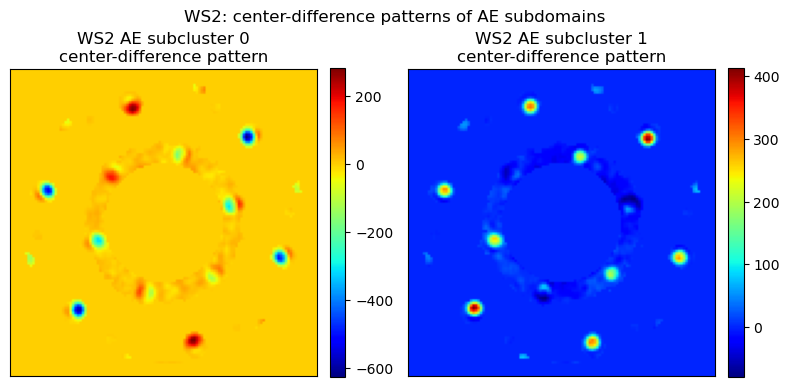

WSe2: region_mask shape: (256, 256)
WSe2: region_dp shape: (16268, 2086)
WSe2: AE subclusters in region = [np.int64(0), np.int64(1)]


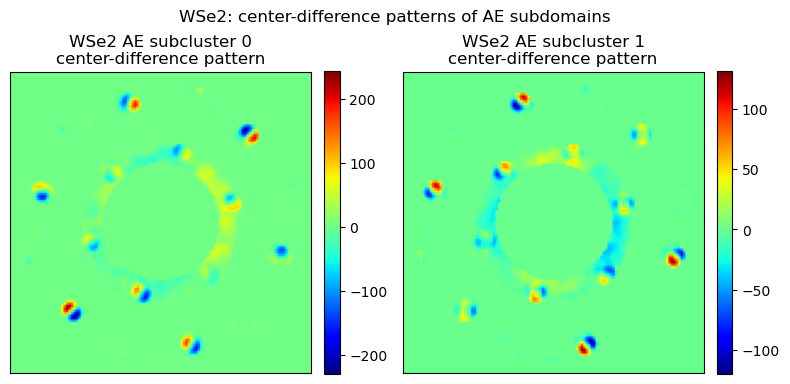

In [61]:
"""
    For a given material (WS2 or WSe2), compute center-difference patterns
    of AE subclusters:

        CDP_k(q) = <I(q)>_cluster_k  -  <I(q)>_material

    where q runs over diffraction pixels selected by std_mask.
"""

def show_center_diff_patterns_AE(label_map_ae, region_mask, material_name,
                                 n_subdomains=2, vmax=None):
    masked = wide_node.std_masked_data      # shape: (Nx, Ny, D_masked)
    Nx, Ny, D_masked = masked.shape

    # Masking for that material in real space
    region_mask = (region_mask > 0)
    print(f"{material_name}: region_mask shape:", region_mask.shape)

    # boolean index of all scan positions inside this material
    region_idx = region_mask

    # all masked diffraction patterns from this material
    region_dp = masked[region_idx]         # shape: (N_region, D_masked)
    print(f"{material_name}: region_dp shape:", region_dp.shape)

    # material-average diffraction (reference "center")
    ref_dp = region_dp.mean(axis=0)        # (D_masked,)

    # std_mask -> positions of masked diffraction pixels
    mask_y, mask_x = np.where(std_mask > 0)

    # AE cluster labels inside this material
    labels_in_region = label_map_ae[region_idx]
    unique_clusters = [c for c in np.unique(labels_in_region) if c >= 0]
    unique_clusters = unique_clusters[:n_subdomains]
    print(f"{material_name}: AE subclusters in region =", unique_clusters)

    if len(unique_clusters) == 0:
        print(f"{material_name}: no AE clusters inside region.")
        return

    # Plotting
    fig, axes = plt.subplots(1, len(unique_clusters),
                             figsize=(4*len(unique_clusters), 4))
    if len(unique_clusters) == 1:
        axes = [axes]

    for ax, cl in zip(axes, unique_clusters):
        # indices of scan positions belonging to this subcluster in this material
        sub_idx = (label_map_ae == cl) & region_mask
        sub_dp  = masked[sub_idx]          # (N_sub, D_masked)

        if sub_dp.shape[0] == 0:
            ax.set_title(f"{material_name} cluster {cl} (empty)")
            ax.axis("off")
            continue

        # mean DP of this subcluster
        sub_mean = sub_dp.mean(axis=0)     # (D_masked,)

        # center-difference vector
        diff_vec = sub_mean - ref_dp      # (D_masked,)

        # map back to 2D diffraction space using std_mask
        pattern = np.zeros_like(std_mask, dtype=float)
        pattern[mask_y, mask_x] = diff_vec

        im = ax.imshow(pattern, cmap="jet", vmax=vmax)
        ax.set_title(f"{material_name} AE subcluster {cl}\ncenter-difference pattern")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.suptitle(f"{material_name}: center-difference patterns of AE subdomains")
    plt.tight_layout()
    plt.show()

# Calling for WS2 and WSe2 (2 subdomains each)
show_center_diff_patterns_AE(label_map_ws2_ae,  ws2_mask,  "WS2",  n_subdomains=2)
show_center_diff_patterns_AE(label_map_wse2_ae, wse2_mask, "WSe2", n_subdomains=2)


### Comparison of AE Clustering With the Reference Results

<br>

The AE–based clustering successfully recovers the material identity and intra-material strain variations observed in the reference segmentation of Shi et al. In the WSe₂ region, the AE reproduces the characteristic ring-like strain gradient that Shi's STD-manifold method identifies, and the corresponding latent-space clusters align with the known radial deformation pattern. For WS₂, the AE also reproduces the two principal subdomains, with center-difference patterns that match the expected symmetry breaking of the Bragg disk intensities.

<br>

However, the AE does not fully separate the subtle angular deformation modes that Shi resolves. This is reflected in the diffuse cluster boundaries and overlap in the 3-D latent space: the AE latent manifold is organized more by overall geometric variation than by fine-scale structural modes. This limitation is also visible in the center-difference patterns, where the AE captures the correct disk positions qualitatively but produces additional large-scale offsets (uniform yellow/blue backgrounds) that are absent in the Shi reference.

<br>

Overall, the AE partially reproduces the key physical motifs—material contrast, radial strain variation, and systematic disk-intensity shifts—but lacks the resolution needed to disentangle the more delicate deformation submodes extracted by Shi's physics-informed manifold learning.

<br><br>

## Variational Autoencoder-Based Dimensionality Reduction and Clustering

<br><br>

In this section, a variational autoencoder (VAE) is employed to obtain a **probabilistic latent representation** of the STD-filtered diffraction data. As in the AE case, only scan positions inside the high-STD mask are retained. The corresponding diffraction patterns are collected into a matrix

<br>

$$X \in \mathbb{R}^{\,N_{\text{valid}} \times D_{\text{masked}}},$$

<br>

where each row corresponds to one valid scan position. Each reciprocal-space feature is standardized across the selected positions, producing a matrix $X_{\text{std}}$ with approximately zero mean and unit variance in every dimension. The standardized data are wrapped into a PyTorch dataset for mini-batch training.

<br>

A variational autoencoder with an 8-dimensional latent space is then constructed. The encoder maps each input vector $x$ into a Gaussian distribution in latent space via two linear heads that output the mean and log-variance,

<br>

$$(\mu(x),\; \log \sigma^2(x)).$$  

<br>

A latent sample is drawn using the reparameterization trick,

<br>

$$
z = \mu(x) + \sigma(x)\,\varepsilon, 
\qquad \varepsilon \sim \mathcal{N}(0, I),
$$

<br>

which ensures differentiability with respect to the encoder parameters. The decoder mirrors the encoder structure and reconstructs a diffraction vector $\hat{x}$ from the sampled latent point $z$.

<br>

The VAE is trained by minimizing a loss function consisting of a reconstruction term and a Kullback–Leibler (KL) divergence term,  

<br>

$$
\mathcal{L}_{\mathrm{VAE}}
=
\lVert x - \hat{x} \rVert^{2}
+
\beta \, D_{\mathrm{KL}}\!\left(
q(z \mid x)\;\|\;p(z)
\right),
$$

<br>

where $q(z \mid x)$ is the encoder distribution and $p(z)$ is the standard normal prior. A small regularization weight $\beta$ is used to prevent the KL term from dominating the training process. Optimization proceeds for 40 epochs using Adam, and the average loss per epoch is printed to track convergence.

<br>

After training, the encoder is evaluated at all valid scan positions, and the latent means

<br>

$$Z_{\mathrm{VAE}} \in \mathbb{R}^{\,N_{\text{valid}} \times 8}$$

<br>

are extracted and used as deterministic embeddings for clustering. K-means clustering with

<br>

$$k = 4$$  

<br>

is then applied in this latent space, and the resulting cluster labels are mapped back into a full $(N_x, N_y)$ grid, with invalid pixels assigned a background label.

<br>

To examine the organization of the learned manifold, the latent codes are projected into three dimensions using PCA. The resulting coordinates

<br>

$$(\mathrm{PC1},\,\mathrm{PC2},\,\mathrm{PC3})$$

<br>

are plotted with colors corresponding to their cluster assignments. This visualization reveals how the VAE organizes patterns in latent space and provides a basis for comparison with both the AE embeddings and the manifold structure derived from the handcrafted STD features.


WS2 (VAE): region_mask shape: (256, 256)
WS2 (VAE): X (region) shape: (3799, 2086)
WS2 (VAE): X_std mean/std = 3.2655950832349845e-08 1.0
WS2 (VAE): using device cuda
WS2 (VAE): input_dim = 2086
[WS2 VAE] Epoch 1/40, loss = 9.995998e-01
[WS2 VAE] Epoch 5/40, loss = 8.720359e-01
[WS2 VAE] Epoch 10/40, loss = 8.605531e-01
[WS2 VAE] Epoch 15/40, loss = 8.540225e-01
[WS2 VAE] Epoch 20/40, loss = 8.488008e-01
[WS2 VAE] Epoch 25/40, loss = 8.443989e-01
[WS2 VAE] Epoch 30/40, loss = 8.406629e-01
[WS2 VAE] Epoch 35/40, loss = 8.368455e-01
[WS2 VAE] Epoch 40/40, loss = 8.328183e-01
WS2 (VAE): Z_reg shape: (3799, 8)
WS2 (VAE): labels_reg shape: (3799,)


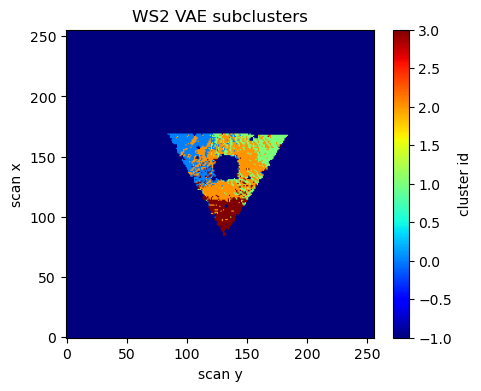

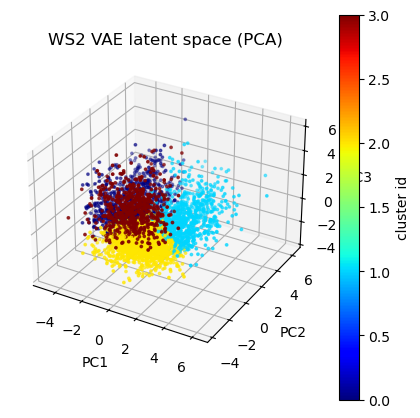

WSe2 (VAE): region_mask shape: (256, 256)
WSe2 (VAE): X (region) shape: (16268, 2086)
WSe2 (VAE): X_std mean/std = -1.394898163198377e-06 1.0000005960464478
WSe2 (VAE): using device cuda
WSe2 (VAE): input_dim = 2086
[WSe2 VAE] Epoch 1/40, loss = 9.441480e-01
[WSe2 VAE] Epoch 5/40, loss = 8.943125e-01
[WSe2 VAE] Epoch 10/40, loss = 8.890626e-01
[WSe2 VAE] Epoch 15/40, loss = 8.856141e-01
[WSe2 VAE] Epoch 20/40, loss = 8.823859e-01
[WSe2 VAE] Epoch 25/40, loss = 8.791549e-01
[WSe2 VAE] Epoch 30/40, loss = 8.755964e-01
[WSe2 VAE] Epoch 35/40, loss = 8.724820e-01
[WSe2 VAE] Epoch 40/40, loss = 8.699780e-01
WSe2 (VAE): Z_reg shape: (16268, 8)
WSe2 (VAE): labels_reg shape: (16268,)


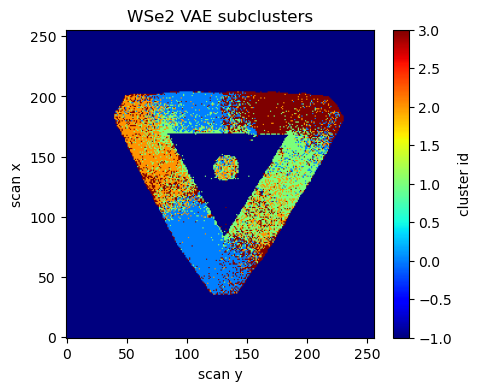

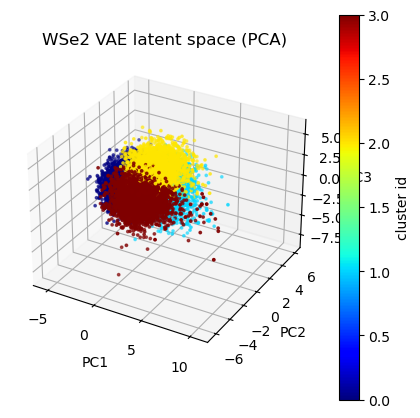

In [62]:
# VAE helper function which will train a VAE only on diffraction patterns within region_mask, then KMeans-cluster the latent means mu(x) and map back to real space.
def vae_latent_subclustering(region_mask, k_sub=4, latent_dim=8, hidden_dim=512,
                             num_epochs=40, batch_size=256, kl_weight=1e-3,
                             region_name="WS2"):
    masked = wide_node.std_masked_data          # (Nx, Ny, D_masked)
    Nx, Ny, D_masked = masked.shape

    # Restricting to region
    region_mask = (region_mask > 0)
    print(f"{region_name} (VAE): region_mask shape:", region_mask.shape)

    masked_flat = masked.reshape(Nx * Ny, D_masked)
    region_flat = region_mask.reshape(Nx * Ny)

    X = masked_flat[region_flat].astype(np.float32)
    print(f"{region_name} (VAE): X (region) shape:", X.shape)

    # feature-wise standardization
    feat_mean = X.mean(axis=0, keepdims=True)
    feat_std  = X.std(axis=0, keepdims=True) + 1e-6
    X_std     = (X - feat_mean) / feat_std
    print(f"{region_name} (VAE): X_std mean/std =",
          float(X_std.mean()), float(X_std.std()))

    # PyTorch dataset
    X_tensor = torch.from_numpy(X_std)
    dataset  = TensorDataset(X_tensor)
    loader   = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"{region_name} (VAE): using device", device)

    input_dim = X_std.shape[1]
    print(f"{region_name} (VAE): input_dim =", input_dim)

    # VAE definition
    class VAE(nn.Module):
        def __init__(self, input_dim, latent_dim=8, hidden_dim=512):
            super().__init__()
            # encoder
            self.fc1     = nn.Linear(input_dim, hidden_dim)
            self.fc_mu   = nn.Linear(hidden_dim, latent_dim)
            self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
            # decoder
            self.fc2     = nn.Linear(latent_dim, hidden_dim)
            self.fc3     = nn.Linear(hidden_dim, input_dim)

        def encode(self, x):
            h = torch.relu(self.fc1(x))
            mu = self.fc_mu(h)
            logvar = self.fc_logvar(h)
            return mu, logvar

        def reparameterize(self, mu, logvar):
            std = torch.exp(0.5 * logvar)
            eps = torch.randn_like(std)
            return mu + eps * std

        def decode(self, z):
            h = torch.relu(self.fc2(z))
            x_recon = self.fc3(h)
            return x_recon

        def forward(self, x):
            mu, logvar = self.encode(x)
            z = self.reparameterize(mu, logvar)
            x_recon = self.decode(z)
            return x_recon, mu, logvar

    def vae_loss_fn(recon_x, x, mu, logvar, kl_weight=1e-3):
        # Reconstruction term
        recon_loss = nn.functional.mse_loss(recon_x, x, reduction="mean")
        # KL term
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
        return recon_loss + kl_weight * kl

    vae = VAE(input_dim=input_dim,
              latent_dim=latent_dim,
              hidden_dim=hidden_dim).to(device)
    optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

    # Training VAE
    vae.train()
    for epoch in range(num_epochs):
        total_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)

            optimizer.zero_grad()
            recon, mu, logvar = vae(batch)
            loss = vae_loss_fn(recon, batch, mu, logvar, kl_weight=kl_weight)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * batch.size(0)

        avg_loss = total_loss / len(dataset)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"[{region_name} VAE] Epoch {epoch+1}/{num_epochs}, "
                  f"loss = {avg_loss:.6e}")

    # latent means
    vae.eval()
    with torch.no_grad():
        X_dev = X_tensor.to(device)
        _, mu_all, logvar_all = vae(X_dev)
        Z_reg = mu_all.cpu().numpy()    # use mu(x) as embedding
    print(f"{region_name} (VAE): Z_reg shape:", Z_reg.shape)

    # KMeans in latent space
    kmeans = KMeans(n_clusters=k_sub, n_init=10, random_state=0)
    labels_reg = kmeans.fit_predict(Z_reg)
    print(f"{region_name} (VAE): labels_reg shape:", labels_reg.shape)

    # Mapping back to real-space label map
    label_map = -1 * np.ones(Nx * Ny, dtype=int)
    label_map[region_flat] = labels_reg
    label_map = label_map.reshape(Nx, Ny)

    plt.figure(figsize=(5, 4))
    im = plt.imshow(label_map, origin="lower", cmap="jet")
    plt.title(f"{region_name} VAE subclusters")
    plt.colorbar(im, label="cluster id")
    plt.xlabel("scan y")
    plt.ylabel("scan x")
    plt.show()

    # PCA to 3D for visualization
    pca = PCA(n_components=3)
    Z_reg_3d = pca.fit_transform(Z_reg)

    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(5, 5))
    ax = fig.add_subplot(111, projection="3d")
    p = ax.scatter(Z_reg_3d[:, 0], Z_reg_3d[:, 1], Z_reg_3d[:, 2],
                   c=labels_reg, s=3, cmap="jet")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_zlabel("PC3")
    ax.set_title(f"{region_name} VAE latent space (PCA)")
    fig.colorbar(p, label="cluster id")
    plt.show()

    return label_map, Z_reg, labels_reg


# Running VAE subclustering for WS2 and WSe2
# (using the same ws2_mask / wse2_mask as in your AE code)

ws2_mask  = (real_space_map_WS2  > 0)
wse2_mask = (real_space_map_WSe2 > 0)

label_map_ws2_vae, Z_ws2_vae, labels_ws2_vae = vae_latent_subclustering(
    ws2_mask, k_sub=4, latent_dim=8, region_name="WS2"
)

label_map_wse2_vae, Z_wse2_vae, labels_wse2_vae = vae_latent_subclustering(
    wse2_mask, k_sub=4, latent_dim=8, region_name="WSe2"
)


WS2 (VAE center-diff): X_region shape: (3799, 2086)
WS2 (VAE center-diff): labels_reg shape: (3799,)


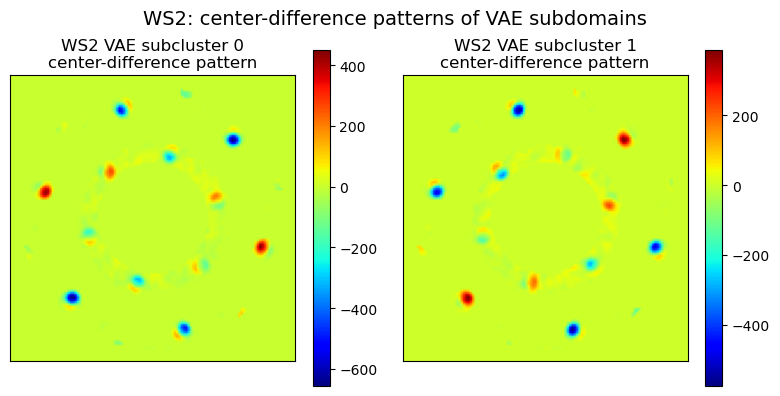

WSe2 (VAE center-diff): X_region shape: (16268, 2086)
WSe2 (VAE center-diff): labels_reg shape: (16268,)


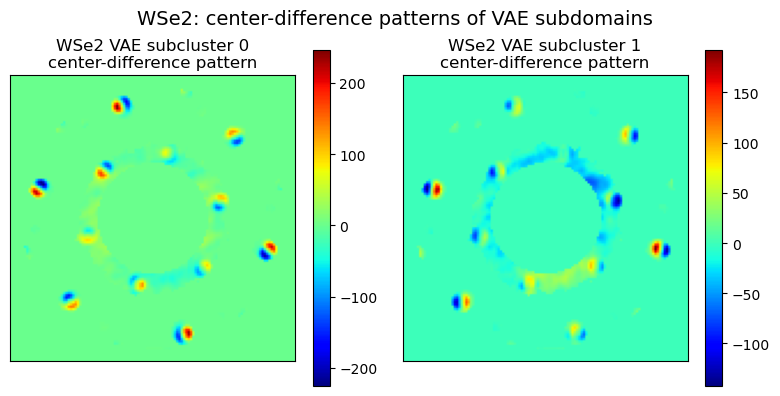

In [63]:
# Center-difference patterns for VAE subdomains

def plot_center_difference_patterns_vae(region_mask, labels_reg, region_name="WS2",
                                        sub_ids=(0, 1)):
    masked = wide_node.std_masked_data      # (Nx, Ny, D_masked)
    Nx, Ny, D_masked = masked.shape

    # Flattening scan grid and restrict to region
    region_mask = (region_mask > 0)
    masked_flat = masked.reshape(Nx * Ny, D_masked)
    region_flat = region_mask.reshape(Nx * Ny)

    # All diffraction vectors in this material region
    X_region = masked_flat[region_flat]     # (N_region, D_masked)
    print(f"{region_name} (VAE center-diff): X_region shape:", X_region.shape)
    print(f"{region_name} (VAE center-diff): labels_reg shape:", labels_reg.shape)

    # Mean diffraction pattern of the whole material region
    center_region = X_region.mean(axis=0)   # (D_masked,)

    # Helper: lifting masked 1D vector back to full DP image using std_mask
    dp_shape = std_mask.shape               # e.g. (124, 124)
    def unmask_pattern(vec):
        img = np.zeros(dp_shape, dtype=np.float32)
        img[std_mask > 0] = vec
        return img

    # Plotting center-difference patterns for chosen subclusters
    n_sub = len(sub_ids)
    fig, axes = plt.subplots(1, n_sub, figsize=(4 * n_sub, 4))
    if n_sub == 1:
        axes = [axes]

    fig.suptitle(f"{region_name}: center-difference patterns of VAE subdomains",
                 fontsize=14)

    for ax, sub_id in zip(axes, sub_ids):
        mask_sub = (labels_reg == sub_id)
        if not np.any(mask_sub):
            print(f"{region_name}: no pixels in subcluster {sub_id}")
            ax.set_visible(False)
            continue

        X_sub = X_region[mask_sub]         # all patterns in this subcluster
        pattern_sub = X_sub.mean(axis=0)   # (D_masked,)
        diff = pattern_sub - center_region # center-difference vector
        diff_img = unmask_pattern(diff)

        im = ax.imshow(diff_img, cmap="jet")
        ax.set_title(f"{region_name} VAE subcluster {sub_id}\ncenter-difference pattern")
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


# Calling for WS2 and WSe2
plot_center_difference_patterns_vae(
    ws2_mask, labels_ws2_vae, region_name="WS2", sub_ids=(0, 1)
)

plot_center_difference_patterns_vae(
    wse2_mask, labels_wse2_vae, region_name="WSe2", sub_ids=(0, 1)
)


### Comparison of VAE Clustering With the Reference Results

<br>

The VAE-based clustering reproduces the major material contrast and large-scale strain variations observed in the reference segmentation of Shi et al., but its ability to separate finer deformation modes is more limited. In both WS₂ and WSe₂, the VAE identifies the correct material domains and assigns distinct clusters to regions differing in radial strain, consistent with the primary organization of Shi’s STD manifold. The latent-space means form compact, approximately Gaussian groups—reflecting the influence of the KL regularization, which drives the latent distribution toward a spherical prior.

<br>

However, the VAE does not capture the detailed angular deformation patterns that characterize the manifold in Shi’s work. In the PCA embeddings, the WS₂ and WSe₂ latent points collapse into smooth, rounded clouds with only partial stratification by strain magnitude, lacking the curved or multi-branch structures associated with directional distortions of the Bragg disks. This smoothing effect is a direct consequence of the variational constraint, which suppresses the formation of separated geometric modes.

<br>

The center-difference patterns extracted from the VAE subclusters correctly reproduce the Bragg-disk locations and their qualitative asymmetries, but the positive and negative lobes are weaker and more diffuse than in the reference. Angular contrasts are diminished, and the WS₂ patterns remain dominated by large-scale background offsets, indicating that the VAE encodes global contrast variations more strongly than orientation-specific strain signatures. The characteristic structured rings seen in Shi’s deformation modes are not recovered.

<br>

Overall, the VAE captures the essential physical motifs at a coarse level, material identity, radial strain gradients, and basic disk-intensity variations, but the KL-regularized latent space limits its ability to express the fine-grained angular deformation submodes extracted by Shi’s physics-informed manifold learning. The resulting representation is smoother and more stable than that of the AE, yet less expressive in terms of subtle structural variation.

<br><br>


### Comparison of AE and VAE Clustering

<br>

A direct comparison of the AE and VAE models reveals clear structural differences in how the two architectures represent and cluster the WS₂ and WSe₂ diffraction datasets.

<br>

**1. Training Behaviour and Loss Profiles**

Across both WS₂ and WSe₂, the AE consistently achieves lower reconstruction loss than the VAE.  
For WS₂, the AE converges from approximately $0.97$ to $0.757$, while the VAE decreases from $0.999$ to $0.832$.  
For WSe₂, the AE decreases from $0.93$ to $0.827$, whereas the VAE remains higher, from $0.94$ to $0.869$.

This gap is expected:  
the AE optimizes only reconstruction, while the VAE optimizes reconstruction **plus** a KL divergence term that regularizes the latent space.  
The KL penalty therefore forces the VAE to adopt smoother latent distributions at the cost of reconstruction fidelity.

<br>

**2. Latent Space Geometry**

The PCA projections show clear differences:

**AE latent spaces** are broader, with more elongated point clouds and sharper separations between clusters. The absence of a prior allows the AE to stretch the latent space along the most informative deformation modes.

**VAE latent spaces** collapse into more compact, spherical point clouds due to the Gaussian prior $p(z) = \mathcal{N}(0, I)$. This leads to more overlap among clusters and reduces the degree of angular separation that the AE is able to preserve.

Thus, the AE provides **higher discriminative resolution**, while the VAE provides **higher smoothness and stability**.

<br>

**3. Real-Space Cluster Maps**

The AE and VAE produce very similar large-scale subdomain segmentations:

- Both successfully isolate the two WS₂ subdomains and the three WSe₂ strain regions.
- Both reproduce the radial strain gradient observed in the WSe₂ flake.
- Both capture the asymmetric WS₂ intensity sectors.

However, the VAE maps are slightly **more diffuse**, with softer boundaries between subdomains. The AE yields **sharper, more spatially coherent clusters**, reflecting its ability to use the full latent capacity without regularization constraints.

<br>

**4. Center-Difference Patterns**

The AE center-difference patterns exhibit:

- stronger contrast,
- clearer disk-intensity asymmetries,
- slightly larger global offsets (uniform yellow/blue backgrounds).

The VAE center-difference patterns display:

- cleaner backgrounds (less global offset),
- smoother disk contrasts,
- but weaker angular modulation and loss of subtle intensity variations.

<br>

**5. Overall Comparison**

The **AE excels at capturing fine deformation modes**, producing sharper clusters, richer angular features, and lower reconstruction error.  

The **VAE excels at producing a coherent, stable latent manifold**, at the cost of blurring small-scale structure and partially merging nearby clusters.

Both methods successfully recover the main material and strain features identified by Shi et al., but the VAE’s KL-regularized latent space trades detail for smoothness, whereas the AE prioritizes fidelity and achieves higher separation in both latent and real space.

<br><br>
